In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy.stats import binned_statistic
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [2]:
FITS_PATH = '/Users/carlimankowski/Downloads/DR19seisages_samp_train456789_net10_method14151617_cluster1819_v2.fits'
hdul = fits.open(FITS_PATH)
data = hdul[1].data
hdul.close()
print(f'Total stars: {len(data):,}')

mask = (
    (data['teff'] > 3700) & (data['teff'] < 5300) &
    (data['logg'] > 0.9)  & (data['logg'] < 3.3)  &
    (data['m_h_atm'] > -2.0) & (data['m_h_atm'] < 0.6) &
    (~data['flag_bad']) &
    np.isfinite(data['fe_h']) & (data['fe_h'] != -9999) &
    np.isfinite(data['c_h']) & (data['c_h'] != -9999) &
    np.isfinite(data['n_h']) & (data['n_h'] != -9999)
)
d = data[mask]
print(f'After cuts: {mask.sum():,} stars')

R_SUN, Z_SUN = 8.122, 0.0208
dist  = d['r_med_geo'] / 1000.0
l_rad = np.radians(d['l']); b_rad = np.radians(d['b'])
x_gc  = dist * np.cos(b_rad) * np.cos(l_rad)
y_gc  = dist * np.cos(b_rad) * np.sin(l_rad)
Rgal  = np.sqrt((x_gc - R_SUN)**2 + y_gc**2)
Zgal  = dist * np.sin(b_rad) + Z_SUN

Total stars: 388,529


After cuts: 351,995 stars


In [3]:
def running_stat(x, y, n_bins=25, x_range=None, stat='median'):
    result, edges, _ = binned_statistic(x, y, statistic=stat, bins=n_bins, range=x_range)
    return 0.5 * (edges[:-1] + edges[1:]), result

def running_percentile(x, y, pct, n_bins=25, x_range=None):
    return running_stat(x, y, n_bins=n_bins, x_range=x_range,
                        stat=lambda v: np.nanpercentile(v, pct))

ALL_NN_COLS = [
    'ZS_AP2_training_Age', 'RF_AP2_training_Age', 'NM_AP2_training_Age',
    'HK_AP3_training_Age', 'RF_AP3_training_Age', 'EP_AP3_training_Age',
    'LM_AK2_training_Age', 'NM_AK2_training_Age', 'EP_AK2_training_Age',
    'ZS_TESS_training_Age', 'HK_TESS_training_Age', 'LM_TESS_training_Age',
]

C_AP2  = '#F50000'
C_AP3  = 'b'
C_AK2  = 'c'
C_TESS = '#A32CDC'

# 3 shades per training set so the three same-set NN methods are distinguishable
# in stacked residual histograms (middle shade is the README baseline color).
SHADES_AP2  = ['#A30000', '#F50000', '#FF7373']
SHADES_AP3  = ['#000080', '#0000FF', '#7373FF']
SHADES_AK2  = ['#008888', '#00CCCC', '#88FFFF']
SHADES_TESS = ['#5C148A', '#A32CDC', '#C77FE8']

TASKS = [
    (14, 'Leung2023_Age',       'Leung+23',
     ['ZS_AP2_training_Age', 'RF_AP2_training_Age', 'NM_AP2_training_Age'],
     ['ZS (AP2)', 'RF (AP2)', 'NM (AP2)'], SHADES_AP2),
    (15, 'Mackereth2019_Age',   'Mackereth+19',
     ['ZS_AP2_training_Age', 'RF_AP2_training_Age', 'NM_AP2_training_Age'],
     ['ZS (AP2)', 'RF (AP2)', 'NM (AP2)'], SHADES_AP2),
    (16, 'StoneMartinez2025_Age', 'Stone-Martinez+25',
     ['HK_AP3_training_Age', 'RF_AP3_training_Age', 'EP_AP3_training_Age'],
     ['HK (AP3)', 'RF (AP3)', 'EP (AP3)'], SHADES_AP3),
    (17, 'StoneMartinez2025_Age', 'Stone-Martinez+25',
     ['LM_AK2_training_Age', 'NM_AK2_training_Age', 'EP_AK2_training_Age'],
     ['LM (AK2)', 'NM (AK2)', 'EP (AK2)'], SHADES_AK2),
]

BEST_COL = 'HK_AP3_training_Age'
AGE_BINS = [
    (0,  4,  '<4 Gyr',    '#440154'),
    (4,  6,  '4-6 Gyr',   '#31688e'),
    (6,  8,  '6-8 Gyr',   '#35b779'),
    (8,  10, '8-10 Gyr',  '#fde725'),
    (10, 12, '10-12 Gyr', '#f58231'),
    (12, 99, '>12 Gyr',   '#e6194b'),
]

---
## Figure 5 — 1:1 Plots: Our NNs vs Literature Ages
4 rows (Tasks 14-17) x 2 cols (1:1 scatter | residual histogram).  
All 3 NN methods per task overlaid with different colors. Dashed line = 1:1.

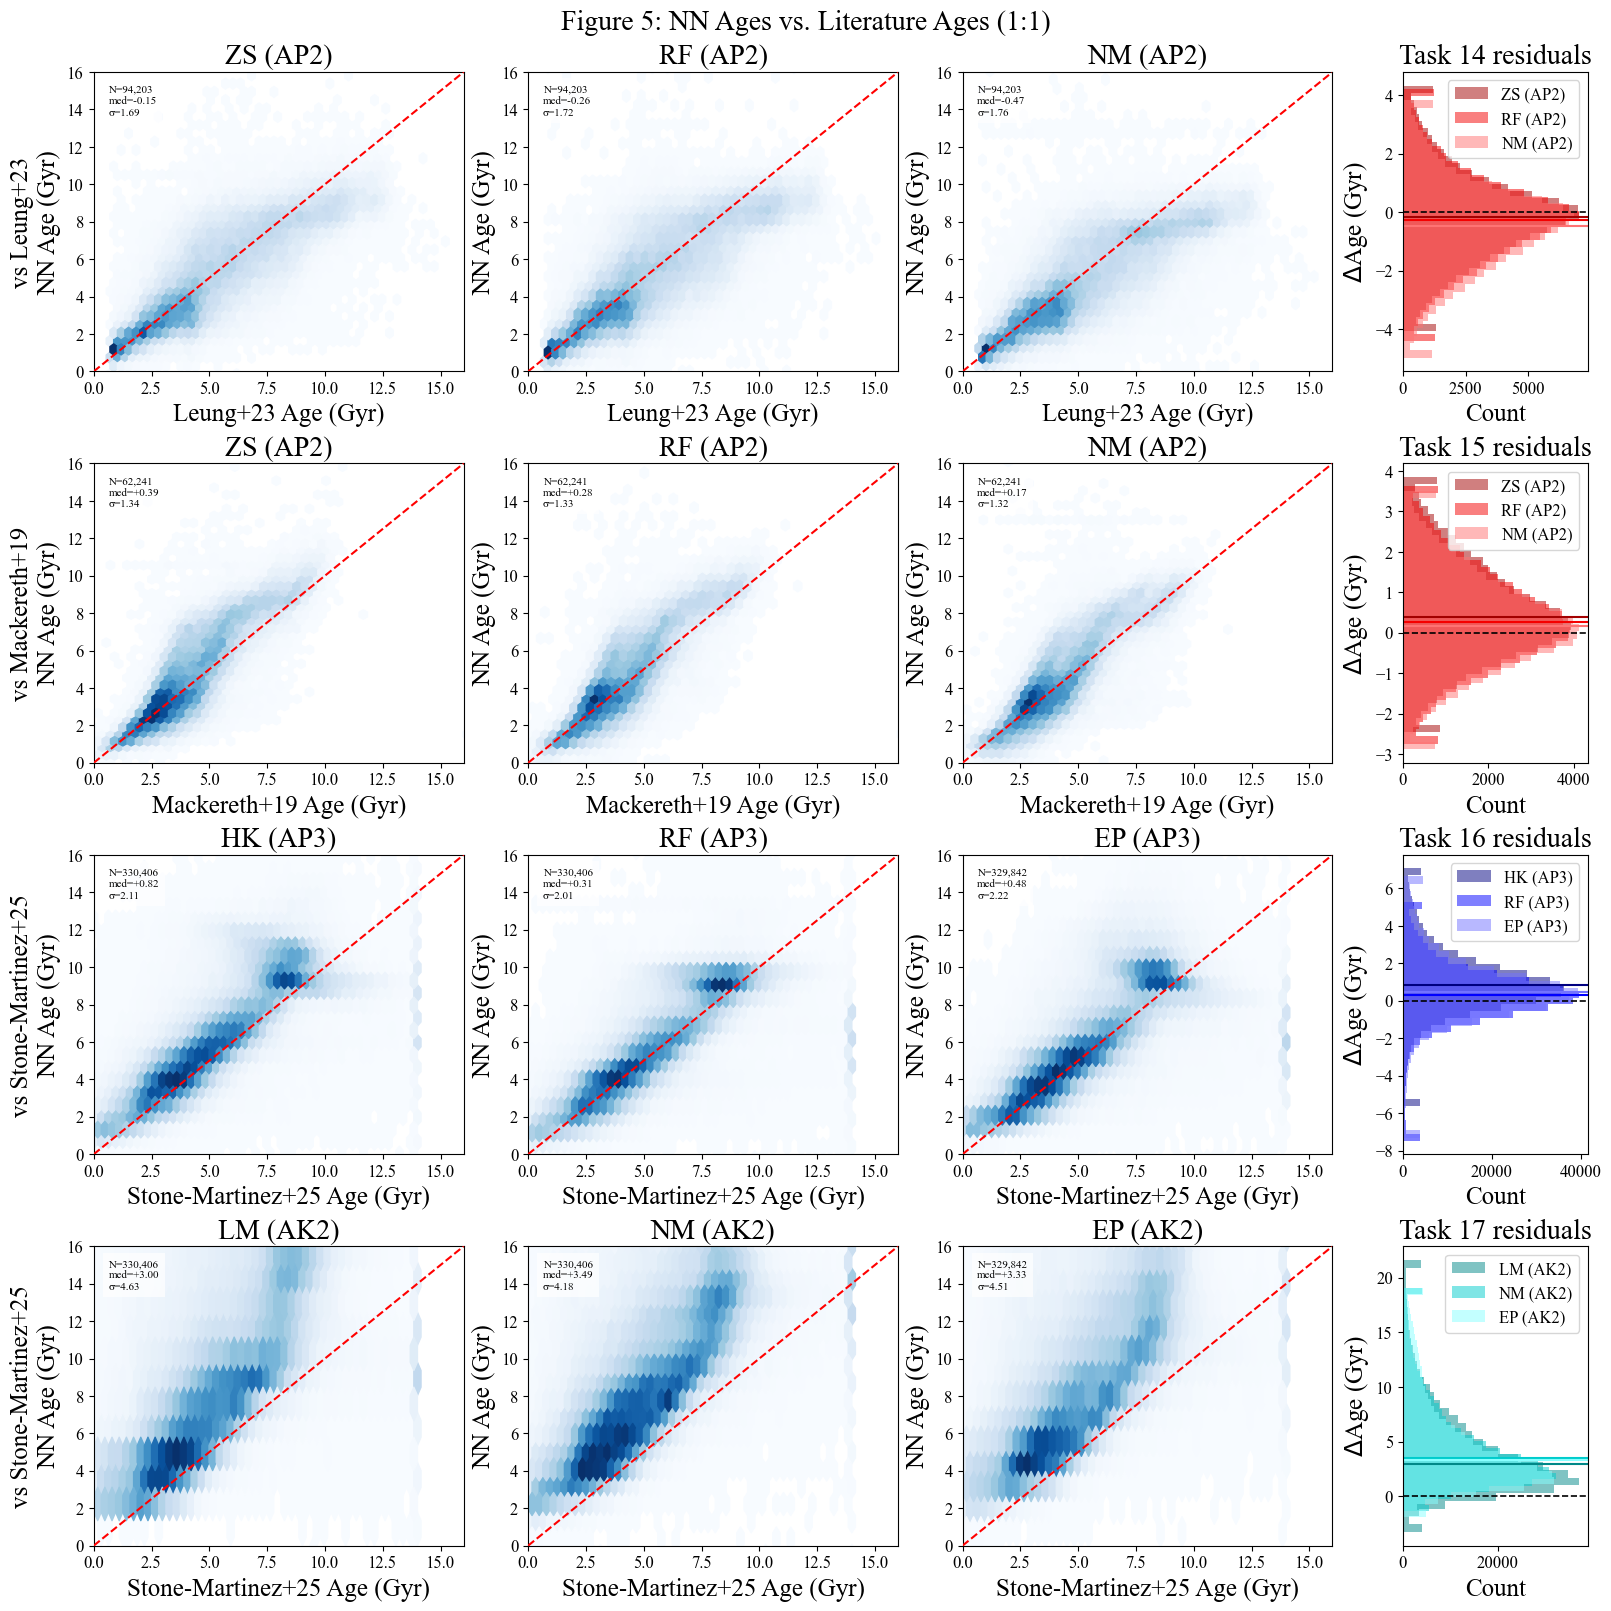

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16), constrained_layout=True,
                         gridspec_kw={'width_ratios': [2, 2, 2, 1]})
fig.suptitle('Figure 5: NN Ages vs. Literature Ages (1:1)', fontsize=20)

for row, (task_id, lit_col, lit_label, nn_cols, nn_labels, colors) in enumerate(TASKS):
    lit_valid = np.isfinite(d[lit_col]) & (d[lit_col] != -9999) & (d[lit_col] > 0)
    ax_hi = axes[row, 3]

    for col, (nn_col, nn_label, color) in enumerate(zip(nn_cols, nn_labels, colors)):
        ax = axes[row, col]
        valid = lit_valid & np.isfinite(d[nn_col]) & (d[nn_col] != -9999)
        lit_age = d[lit_col][valid]
        nn_age  = d[nn_col][valid]
        offset  = nn_age - lit_age

        ax.hexbin(lit_age, nn_age, gridsize=45, cmap='Blues', mincnt=1)
        ax.plot([0, 16], [0, 16], 'r--', lw=1.5, zorder=5)
        ax.set_xlim(0, 16); ax.set_ylim(0, 16)
        ax.set_xlabel(f'{lit_label} Age (Gyr)')
        ax.set_ylabel('NN Age (Gyr)')
        ax.set_title(f'{nn_label}')

        med = np.nanmedian(offset[np.isfinite(offset)])
        std = np.nanstd(offset[np.isfinite(offset)])
        ax.text(0.04, 0.96, f'N={valid.sum():,}\nmed={med:+.2f}\nσ={std:.2f}',
                transform=ax.transAxes, fontsize=8, va='top',
                bbox=dict(fc='white', alpha=0.7, ec='none'))

        finite = offset[np.isfinite(offset)]
        lo, hi = np.nanpercentile(finite, 1), np.nanpercentile(finite, 99)
        ax_hi.hist(np.clip(finite, lo, hi), bins=35, orientation='horizontal',
                   color=color, alpha=0.5, edgecolor='none', label=nn_label)
        ax_hi.axhline(np.median(finite), color=color, lw=1.5, ls='-')

    ax_hi.axhline(0, color='k', lw=1.2, ls='--')
    ax_hi.set_xlabel('Count')
    ax_hi.set_ylabel(r'$\Delta$Age (Gyr)')
    ax_hi.set_title(f'Task {task_id} residuals')
    ax_hi.legend(loc='upper right')
    axes[row, 0].set_ylabel(f'vs {lit_label}\nNN Age (Gyr)')

plt.savefig('figure5_onetoone.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 6 — NN vs. Literature Age Offsets vs. Stellar Parameters (Tasks 14-17)

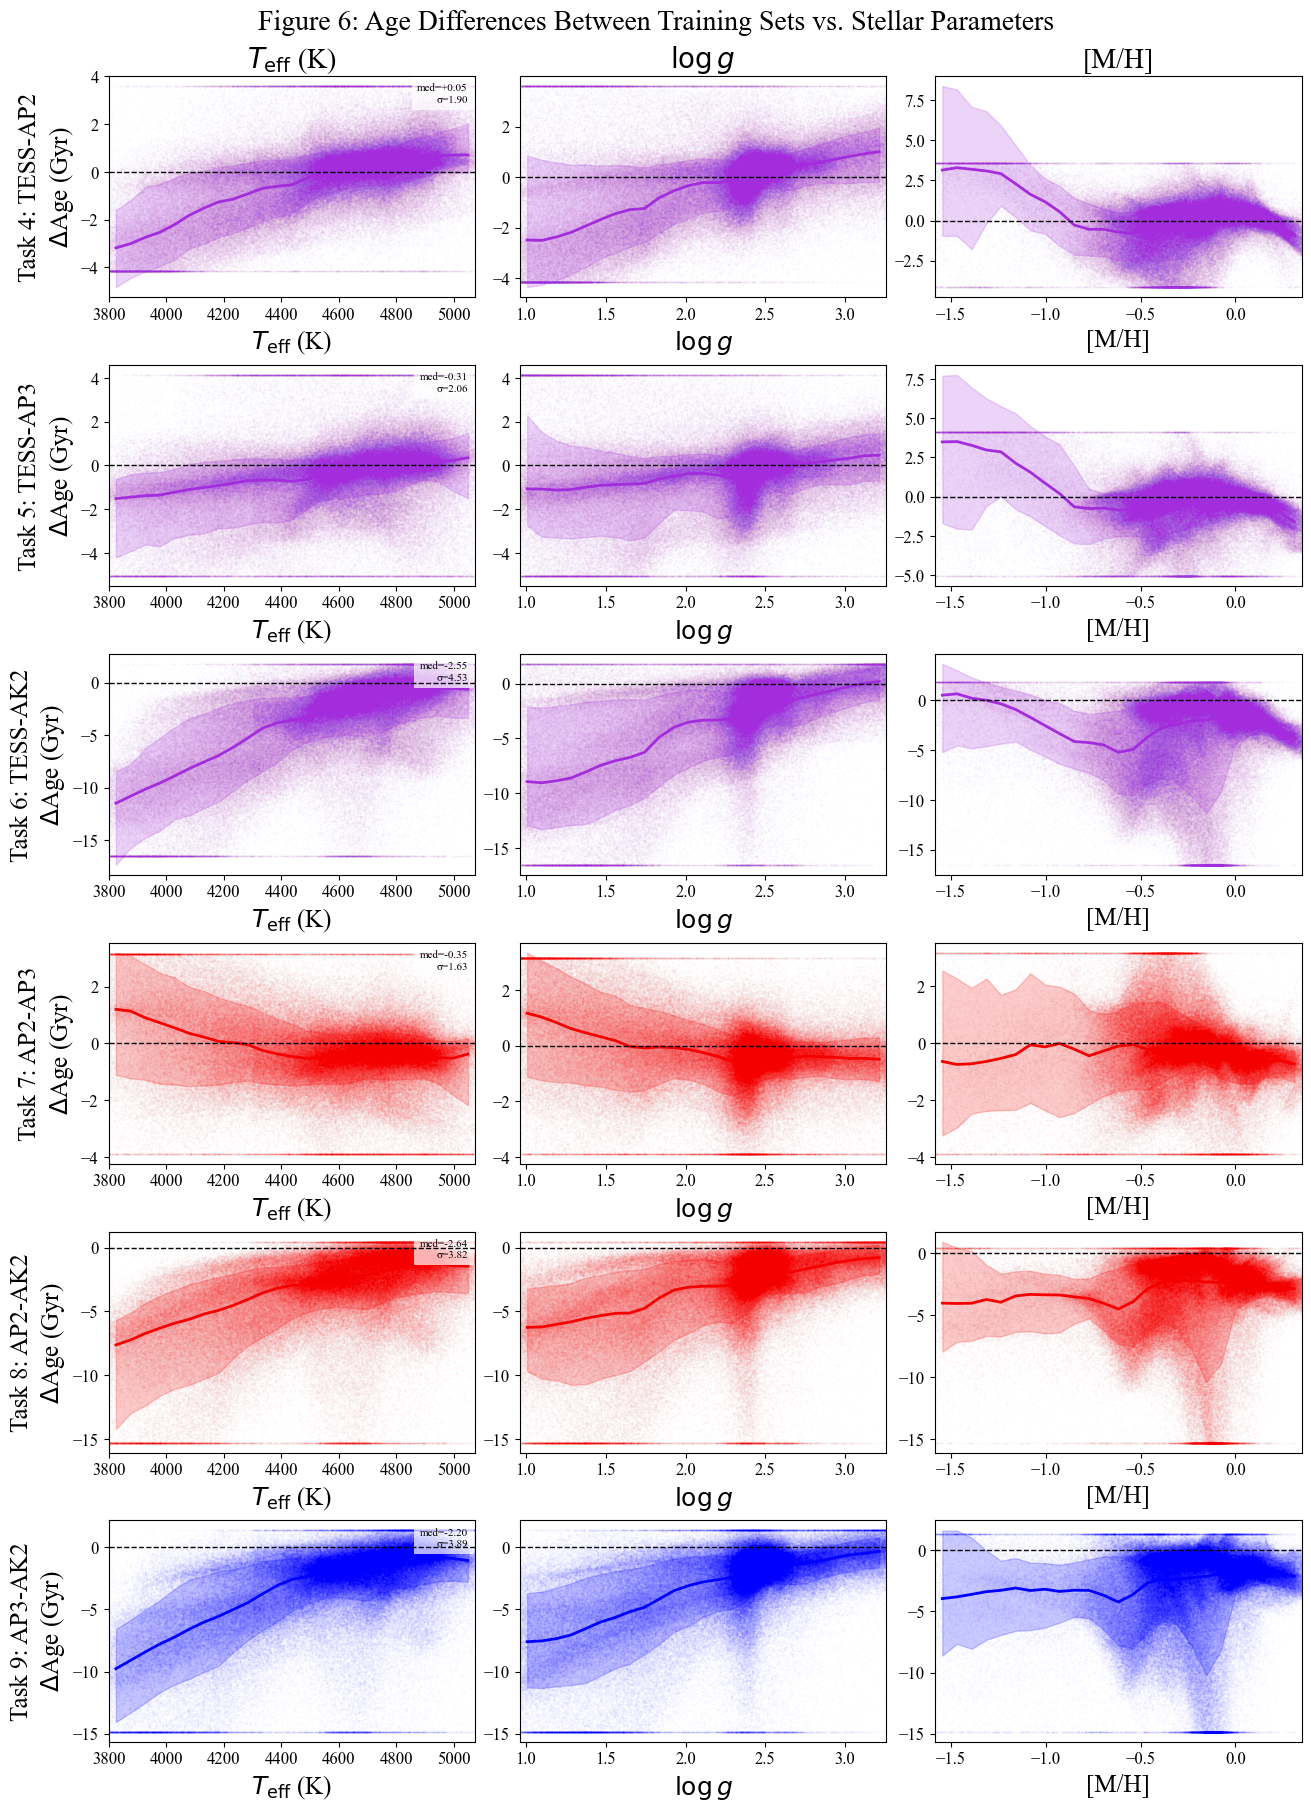

In [5]:
REP = {
    'TESS': 'ZS_TESS_training_Age',
    'AP2':  'ZS_AP2_training_Age',
    'AP3':  'HK_AP3_training_Age',
    'AK2':  'LM_AK2_training_Age',
}
PAIRS = [
    ('TESS', 'AP2',  'Task 4'),
    ('TESS', 'AP3',  'Task 5'),
    ('TESS', 'AK2',  'Task 6'),
    ('AP2',  'AP3',  'Task 7'),
    ('AP2',  'AK2',  'Task 8'),
    ('AP3',  'AK2',  'Task 9'),
]
PAIR_COLORS = [C_TESS, C_TESS, C_TESS, C_AP2, C_AP2, C_AP3]
FIG6_PARAMS = ['teff',      'logg',    'm_h_atm']
FIG6_LABELS = [r'$T_{\rm eff}$ (K)', r'$\log g$', r'[M/H]']
N_BINS = 25

fig, axes = plt.subplots(6, 3, figsize=(13, 18), constrained_layout=True)
fig.suptitle('Figure 6: Age Differences Between Training Sets vs. Stellar Parameters', fontsize=20)

for row, ((s1, s2, task_label), color) in enumerate(zip(PAIRS, PAIR_COLORS)):
    col1 = REP[s1]; col2 = REP[s2]
    both_valid = (np.isfinite(d[col1]) & (d[col1] != -9999) &
                  np.isfinite(d[col2]) & (d[col2] != -9999))

    for col_idx, (param, plabel) in enumerate(zip(FIG6_PARAMS, FIG6_LABELS)):
        ax = axes[row, col_idx]
        mask = both_valid & np.isfinite(d[param])
        x = d[param][mask]
        offset = d[col1][mask] - d[col2][mask]

        x_range = (np.nanpercentile(x, 1), np.nanpercentile(x, 99))
        clip_lo, clip_hi = np.nanpercentile(offset, 2), np.nanpercentile(offset, 98)

        ax.scatter(x, np.clip(offset, clip_lo, clip_hi),
                   c=color, alpha=0.03, s=0.1, rasterized=True)

        xmed, ymed = running_stat(x, offset, n_bins=N_BINS, x_range=x_range)
        _, y16 = running_percentile(x, offset, 16, n_bins=N_BINS, x_range=x_range)
        _, y84 = running_percentile(x, offset, 84, n_bins=N_BINS, x_range=x_range)
        ok = np.isfinite(ymed)
        ax.plot(xmed[ok], ymed[ok], color=color, lw=2)
        ax.fill_between(xmed[ok], y16[ok], y84[ok], color=color, alpha=0.2)

        ax.axhline(0, color='k', lw=1.0, ls='--', zorder=5)
        ax.set_xlabel(plabel)
        ax.set_xlim(x_range)

        if col_idx == 0:
            med = np.nanmedian(offset[np.isfinite(offset)])
            std = np.nanstd(offset[np.isfinite(offset)])
            ax.set_ylabel(f'{task_label}: {s1}-{s2}\n' + r'$\Delta$Age (Gyr)')
            ax.text(0.98, 0.97, f'med={med:+.2f}\nσ={std:.2f}',
                    transform=ax.transAxes, fontsize=8, ha='right', va='top',
                    bbox=dict(fc='white', alpha=0.7, ec='none'))

for col_idx, plabel in enumerate(FIG6_LABELS):
    axes[0, col_idx].set_title(plabel)

plt.savefig('figure6_training_diffs.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 7 — Cluster Age Validation

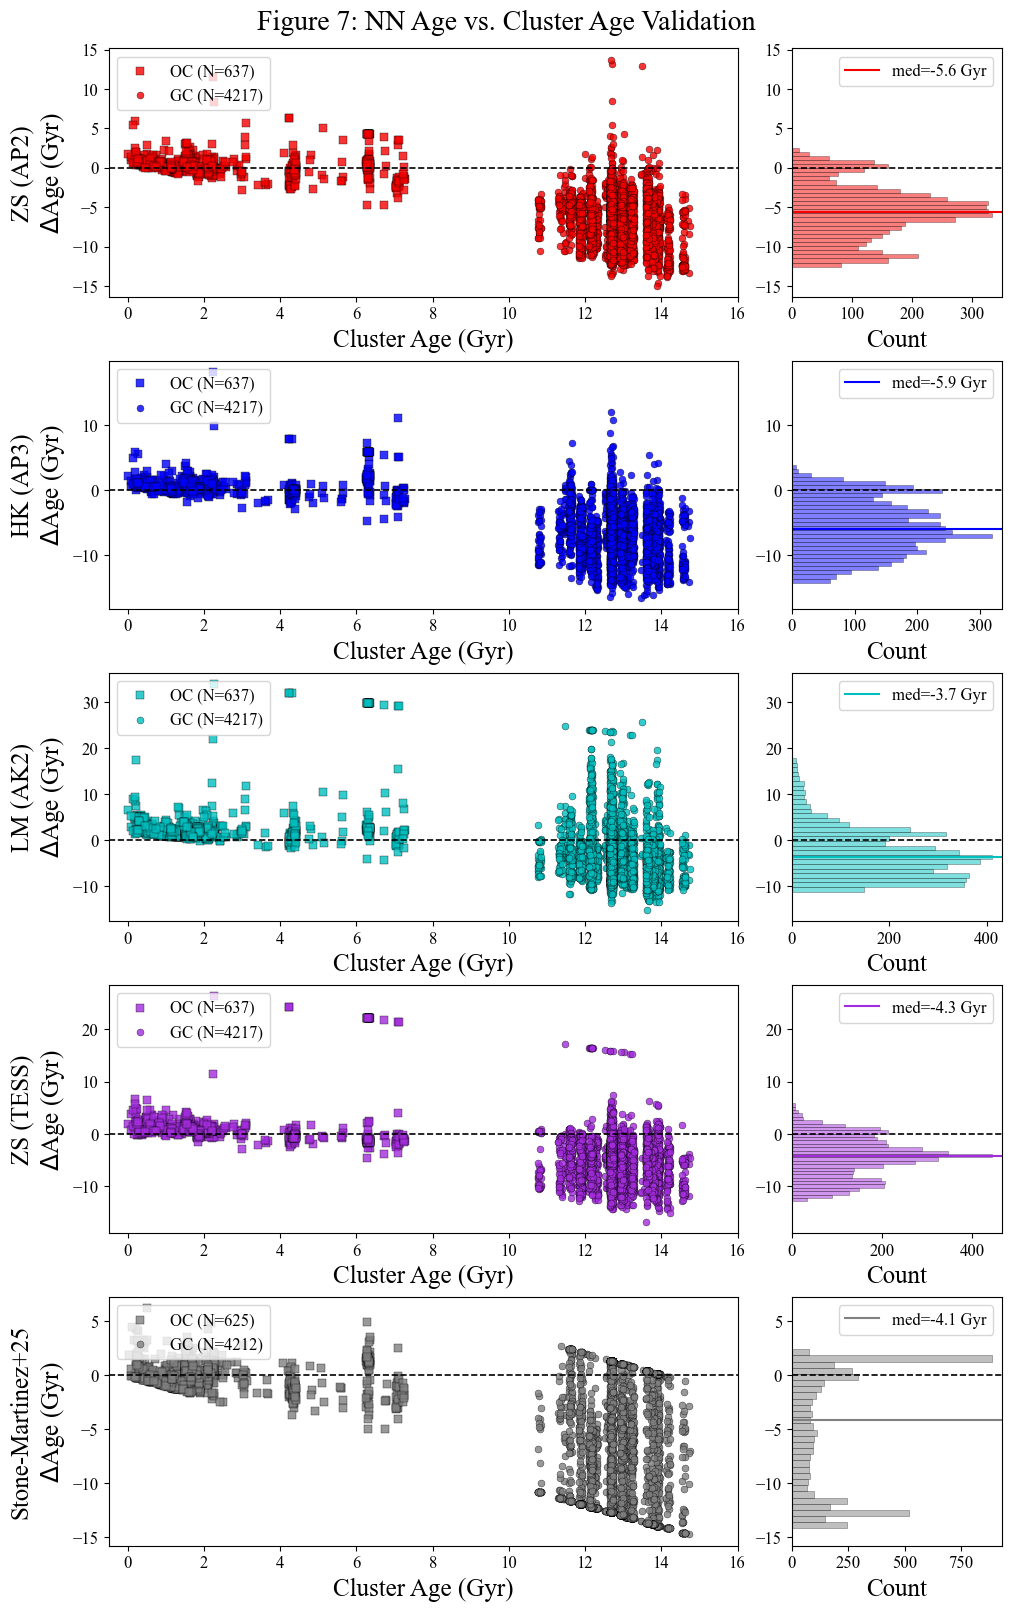

In [6]:
METHODS_FIG7 = [
    ('ZS (AP2)',           'ZS_AP2_training_Age',   C_AP2),
    ('HK (AP3)',           'HK_AP3_training_Age',   C_AP3),
    ('LM (AK2)',           'LM_AK2_training_Age',   C_AK2),
    ('ZS (TESS)',          'ZS_TESS_training_Age',  C_TESS),
    ('Stone-Martinez+25',  'StoneMartinez2025_Age', 'grey'),
]
oc_mask = np.isfinite(data['Cluster_CG20_Age']) & (data['Cluster_CG20_Age'] > 0)
gc_mask = np.isfinite(data['Cluster_D07_Age'])  & (data['Cluster_D07_Age'] > 0)
oc = data[oc_mask]; gc = data[gc_mask]

N = len(METHODS_FIG7)
fig, axes = plt.subplots(N, 2, figsize=(10, 3.2 * N), constrained_layout=True,
                         gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle('Figure 7: NN Age vs. Cluster Age Validation', fontsize=20)

for row, (label, nn_col, color) in enumerate(METHODS_FIG7):
    ax_sc, ax_hi = axes[row, 0], axes[row, 1]
    all_offsets = []
    for subset, clust_col, marker, msize, alpha, ctype in [
        (oc, 'Cluster_CG20_Age', 's', 40, 0.8, 'OC'),
        (gc, 'Cluster_D07_Age',  'o', 25, 0.8, 'GC'),
    ]:
        nn_valid = np.isfinite(subset[nn_col]) & (subset[nn_col] != -9999)
        if nn_valid.sum() == 0: continue
        clust_age = subset[clust_col][nn_valid]
        offset = subset[nn_col][nn_valid] - clust_age
        jitter = np.random.default_rng(42).uniform(-0.05, 0.05, size=len(clust_age))
        ax_sc.scatter(clust_age + jitter, offset, c=color, marker=marker, s=msize,
                      alpha=alpha, edgecolors='k', linewidths=0.3, label=f'{ctype} (N={nn_valid.sum()})')
        all_offsets.append(offset)
    ax_sc.axhline(0, color='k', lw=1.2, ls='--')
    ax_sc.set_xlabel('Cluster Age (Gyr)'); ax_sc.set_xlim(-0.5, 16)
    ax_sc.set_ylabel(f'{label}\n' + r'$\Delta$Age (Gyr)')
    ax_sc.legend(loc='upper left')
    if all_offsets:
        combined = np.concatenate(all_offsets)
        finite = combined[np.isfinite(combined)]
        bins = np.linspace(np.nanpercentile(finite, 1), np.nanpercentile(finite, 99), 30)
        ax_hi.hist(finite, bins=bins, orientation='horizontal',
                   color=color, alpha=0.5, edgecolor='k', linewidth=0.4)
        ax_hi.axhline(0, color='k', lw=1.2, ls='--')
        med = np.median(finite)
        ax_hi.axhline(med, color=color, lw=1.5, ls='-', label=f'med={med:.1f} Gyr')
        ax_hi.set_xlabel('Count'); ax_hi.legend()
        ax_hi.set_ylim(ax_sc.get_ylim())

plt.savefig('figure7_cluster_validation.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 8 — Which Stars Change the Most Between Methods?

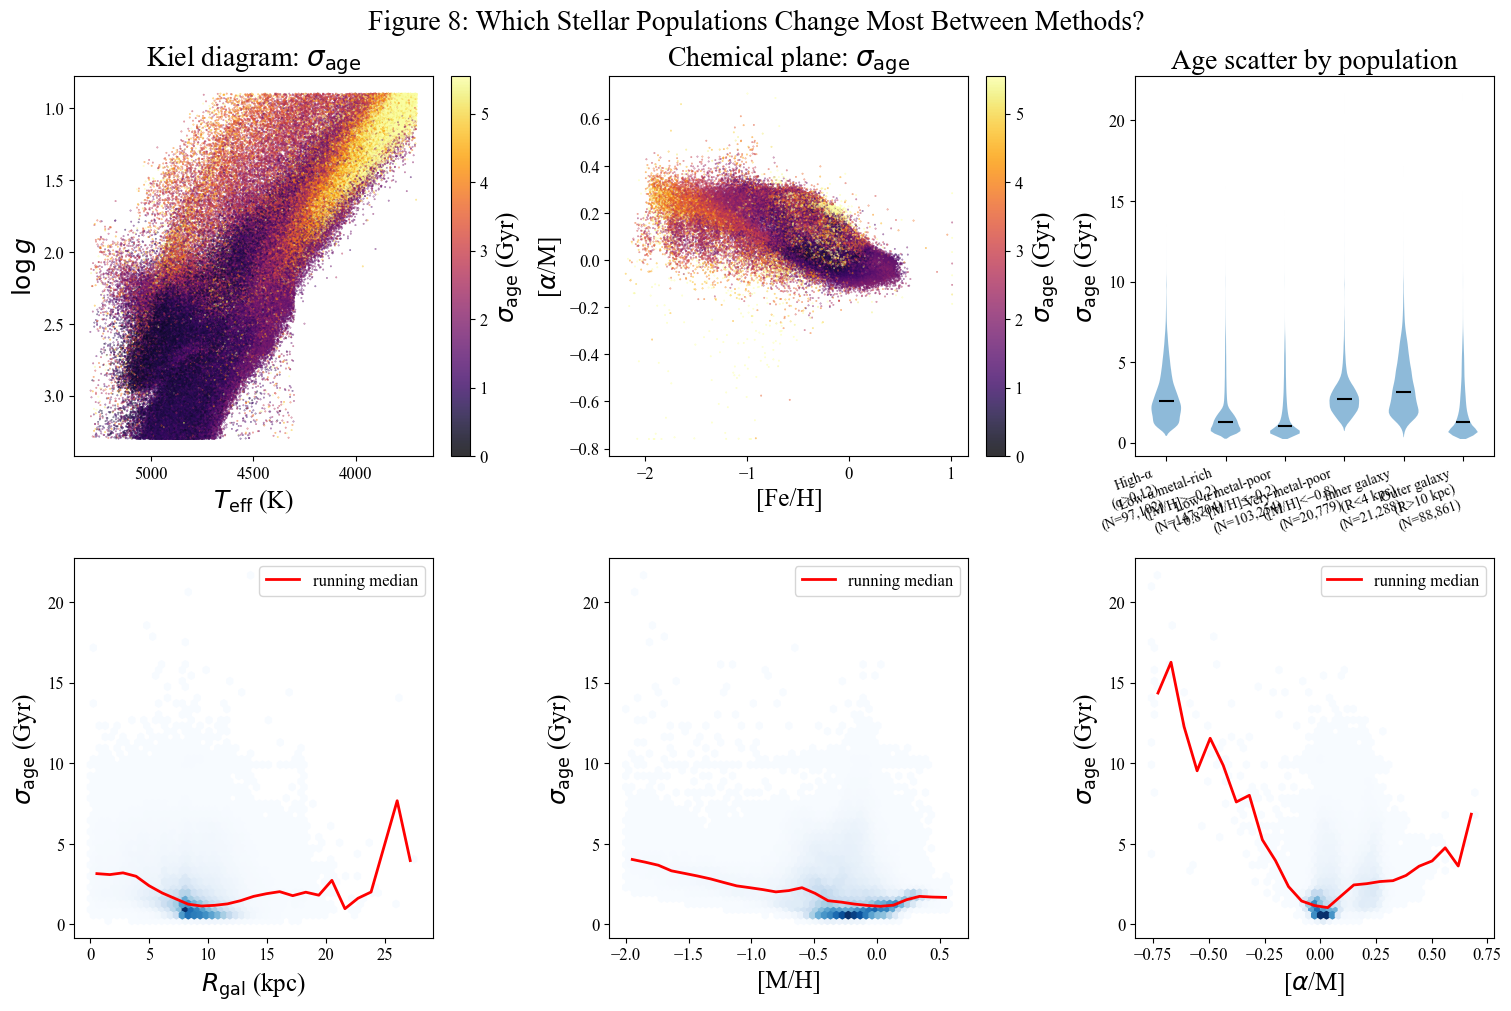

In [7]:
nn_stack = np.column_stack([d[col] for col in ALL_NN_COLS]).astype(float)
nn_stack[nn_stack == -9999] = np.nan
age_std = np.nanstd(nn_stack, axis=1)
good    = np.sum(np.isfinite(nn_stack), axis=1) >= 6

std_g  = age_std[good]
teff_g = d['teff'][good].astype(float)
logg_g = d['logg'][good].astype(float)
mh_g   = d['m_h_atm'][good].astype(float)
alph_g = d['alpha_m_atm'][good].astype(float)
feh_g  = d['fe_h'][good].astype(float)
Rgal_g = Rgal[good]

POPS = [
    ('High-α\n(α>0.12)',                alph_g > 0.12),
    ('Low-α metal-rich\n([M/H]>−0.2)',  (alph_g <= 0.12) & (mh_g > -0.2)),
    ('Low-α metal-poor\n(−0.8<[M/H]≤−0.2)', (alph_g <= 0.12) & (mh_g > -0.8) & (mh_g <= -0.2)),
    ('Very metal-poor\n([M/H]<−0.8)',   mh_g < -0.8),
    ('Inner galaxy\n(R<4 kpc)',         Rgal_g < 4.0),
    ('Outer galaxy\n(R>10 kpc)',        Rgal_g > 10.0),
]

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
fig.suptitle('Figure 8: Which Stellar Populations Change Most Between Methods?', fontsize=20)
gs = fig.add_gridspec(2, 3)
vmax = np.nanpercentile(std_g, 95)

ax_kiel = fig.add_subplot(gs[0, 0])
sc = ax_kiel.scatter(teff_g, logg_g, c=std_g, cmap='inferno', vmin=0, vmax=vmax,
                     s=0.1, alpha=0.8, rasterized=True)
ax_kiel.invert_xaxis(); ax_kiel.invert_yaxis()
ax_kiel.set_xlabel(r'$T_{\rm eff}$ (K)'); ax_kiel.set_ylabel(r'$\log g$')
ax_kiel.set_title(r'Kiel diagram: $\sigma_{\rm age}$')
plt.colorbar(sc, ax=ax_kiel, label=r'$\sigma_{\rm age}$ (Gyr)')

ax_chem = fig.add_subplot(gs[0, 1])
ok_chem = np.isfinite(feh_g) & np.isfinite(alph_g) & np.isfinite(std_g)
sc2 = ax_chem.scatter(feh_g[ok_chem], alph_g[ok_chem], c=std_g[ok_chem],
                      cmap='inferno', vmin=0, vmax=vmax, s=0.1, alpha=0.8, rasterized=True)
ax_chem.set_xlabel('[Fe/H]'); ax_chem.set_ylabel(r'[$\alpha$/M]')
ax_chem.set_title(r'Chemical plane: $\sigma_{\rm age}$')
plt.colorbar(sc2, ax=ax_chem, label=r'$\sigma_{\rm age}$ (Gyr)')

ax_viol = fig.add_subplot(gs[0, 2])
pop_data, pop_labels = [], []
for pname, pmask in POPS:
    vals = std_g[pmask & np.isfinite(std_g)]
    pop_data.append(vals)
    pop_labels.append(f'{pname}\n(N={len(vals):,})')
parts = ax_viol.violinplot(pop_data, showmedians=True, showextrema=False)
for pc in parts['bodies']:
    pc.set_alpha(0.5)
parts['cmedians'].set_color('k')
ax_viol.set_xticks(range(1, len(pop_labels) + 1))
ax_viol.set_xticklabels(pop_labels, fontsize=10, rotation=20, ha='right')
ax_viol.set_ylabel(r'$\sigma_{\rm age}$ (Gyr)')
ax_viol.set_title('Age scatter by population')

for ax, x, xl in [
    (fig.add_subplot(gs[1, 0]), Rgal_g, r'$R_{\rm gal}$ (kpc)'),
    (fig.add_subplot(gs[1, 1]), mh_g,   '[M/H]'),
    (fig.add_subplot(gs[1, 2]), alph_g, r'[$\alpha$/M]'),
]:
    ok = np.isfinite(x) & np.isfinite(std_g)
    ax.hexbin(x[ok], std_g[ok], gridsize=55, cmap='Blues', mincnt=1)
    xmed, ymed = running_stat(x[ok], std_g[ok], n_bins=25)
    ok2 = np.isfinite(ymed)
    ax.plot(xmed[ok2], ymed[ok2], 'r-', lw=2, label='running median')
    ax.set_xlabel(xl); ax.set_ylabel(r'$\sigma_{\rm age}$ (Gyr)')
    ax.legend()

plt.savefig('figure8_population_scatter.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 9 — [α/M] vs [Fe/H] in Age Bins

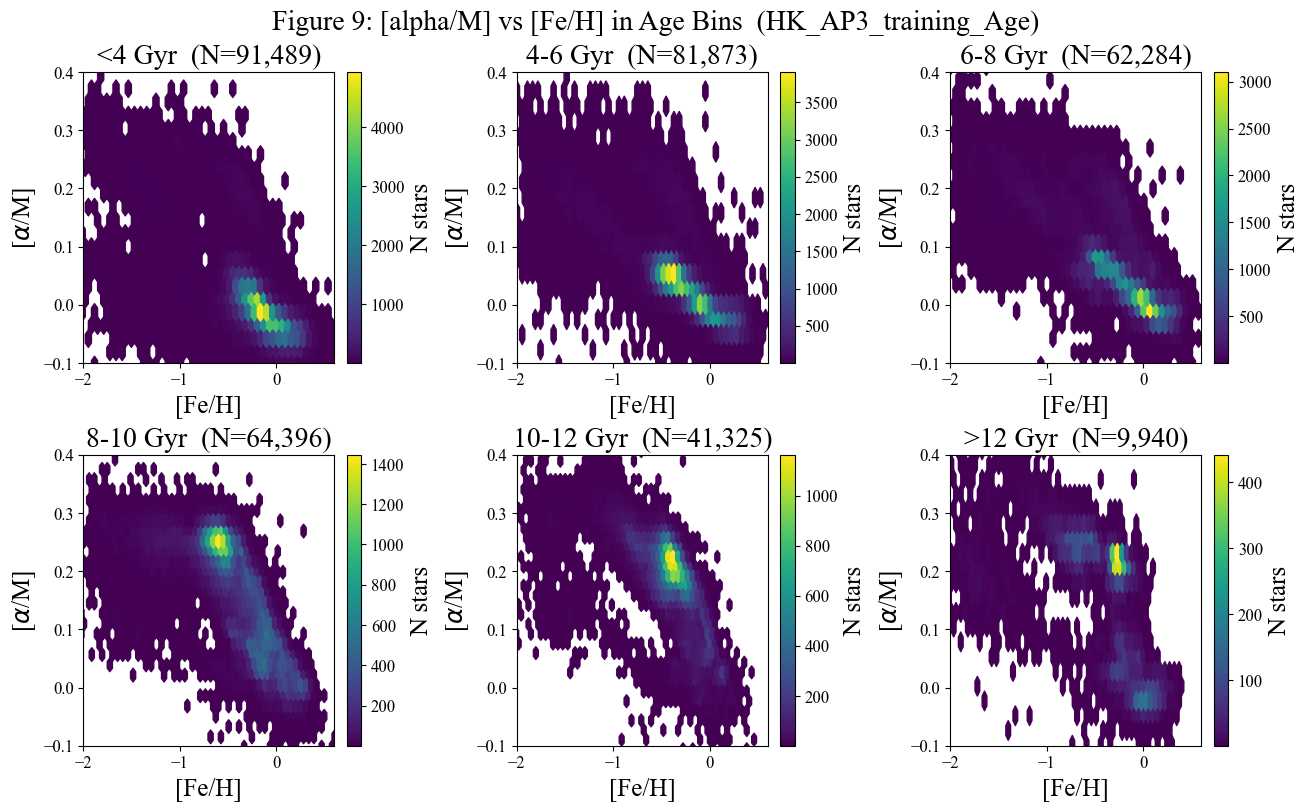

In [8]:
ages  = d[BEST_COL].astype(float); ages[ages == -9999] = np.nan
feh   = d['fe_h'].astype(float)
alpha = d['alpha_m_atm'].astype(float)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
fig.suptitle(f'Figure 9: [alpha/M] vs [Fe/H] in Age Bins  ({BEST_COL})', fontsize=20)
axes = axes.flatten()

for ax, (lo, hi, label, _) in zip(axes, AGE_BINS):
    in_bin = (ages >= lo) & (ages < hi) & np.isfinite(feh) & np.isfinite(alpha)
    hb = ax.hexbin(feh[in_bin], alpha[in_bin], gridsize=50, cmap='viridis', mincnt=1)
    ax.set_xlabel('[Fe/H]'); ax.set_ylabel(r'[$\alpha$/M]')
    ax.set_title(f'{label}  (N={in_bin.sum():,})')
    ax.set_xlim(-2.0, 0.6); ax.set_ylim(-0.1, 0.4)
    plt.colorbar(hb, ax=ax, label='N stars')

plt.savefig('figure9_alpha_feh_agebins.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 10 — Z_gal vs R_gal in Age Bins

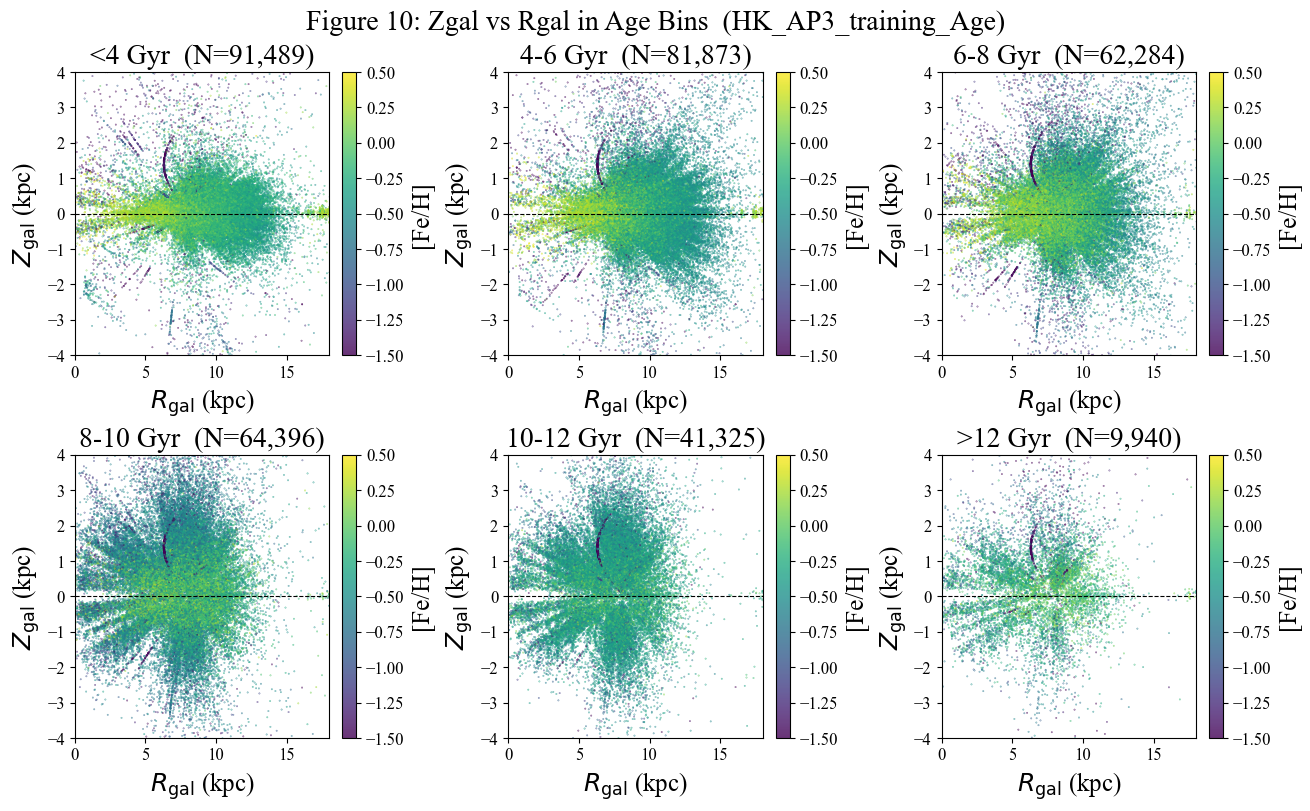

In [9]:
dist_valid = np.isfinite(Rgal) & np.isfinite(Zgal) & np.isfinite(ages)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
fig.suptitle(f'Figure 10: Zgal vs Rgal in Age Bins  ({BEST_COL})', fontsize=20)
axes = axes.flatten()

for ax, (lo, hi, label, _) in zip(axes, AGE_BINS):
    in_bin = (ages >= lo) & (ages < hi) & dist_valid
    sc = ax.scatter(Rgal[in_bin], Zgal[in_bin],
                    c=feh[in_bin], cmap='viridis', vmin=-1.5, vmax=0.5,
                    s=0.1, alpha=0.8, rasterized=True)
    ax.set_xlabel(r'$R_{\rm gal}$ (kpc)'); ax.set_ylabel(r'$Z_{\rm gal}$ (kpc)')
    ax.set_title(f'{label}  (N={in_bin.sum():,})')
    ax.set_xlim(0, 18); ax.set_ylim(-4, 4)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    plt.colorbar(sc, ax=ax, label='[Fe/H]')

plt.savefig('figure10_zgal_rgal_agebins.pdf', dpi=600, bbox_inches='tight')
plt.show()

---
## Figure 11 — Kiel Diagram by [M/H] Bin, Colored by Age

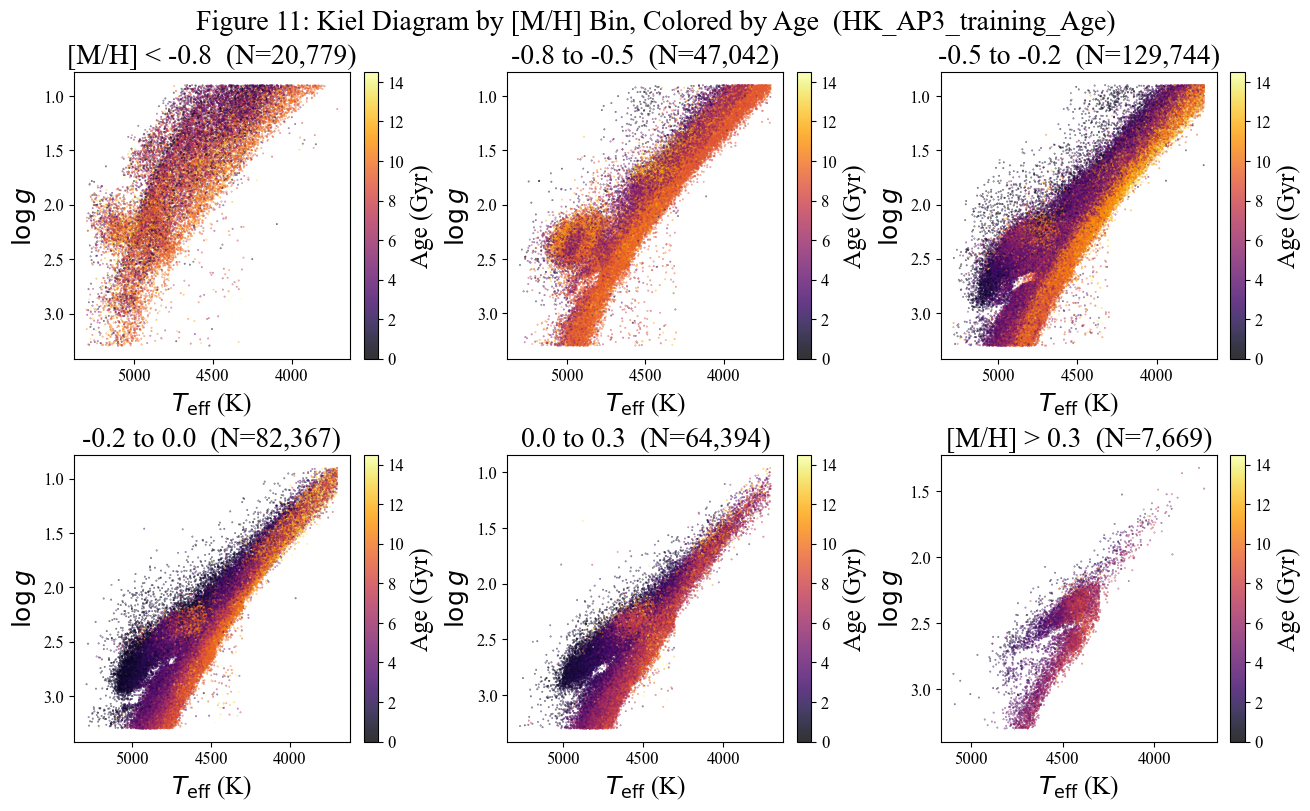

In [10]:
MH_BINS = [
    (-2.0, -0.8, '[M/H] < -0.8'),
    (-0.8, -0.5, '-0.8 to -0.5'),
    (-0.5, -0.2, '-0.5 to -0.2'),
    (-0.2,  0.0, '-0.2 to 0.0'),
    ( 0.0,  0.3, '0.0 to 0.3'),
    ( 0.3,  0.6, '[M/H] > 0.3'),
]
mh     = d['m_h_atm'].astype(float)
teff_d = d['teff'].astype(float)
logg_d = d['logg'].astype(float)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
fig.suptitle(f'Figure 11: Kiel Diagram by [M/H] Bin, Colored by Age  ({BEST_COL})', fontsize=20)
axes = axes.flatten()

for ax, (lo, hi, label) in zip(axes, MH_BINS):
    in_bin = (mh >= lo) & (mh < hi) & np.isfinite(ages) & np.isfinite(teff_d)
    sc = ax.scatter(teff_d[in_bin], logg_d[in_bin], c=ages[in_bin],
                    cmap='inferno', vmin=0, vmax=14.5, s=0.1, alpha=0.8, rasterized=True)
    ax.invert_xaxis(); ax.invert_yaxis()
    ax.set_xlabel(r'$T_{\rm eff}$ (K)'); ax.set_ylabel(r'$\log g$')
    ax.set_title(f'{label}  (N={in_bin.sum():,})')
    plt.colorbar(sc, ax=ax, label='Age (Gyr)')

plt.savefig('figure11_kiel_mhbins.pdf', dpi=600, bbox_inches='tight')
plt.show()